In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Making fig 1 - Curvature

In [2]:
grand_folder = '24_06_Figure_data/fig1/'

iso_up      = np.load(grand_folder + 'iso_up_20/data.pkl', allow_pickle=True)
iso_down    = np.load(grand_folder + 'iso_down_20/data.pkl', allow_pickle=True)
pringle_du  = np.load(grand_folder + 'pringle_downup_20/data.pkl', allow_pickle=True)
pringle_ud  = np.load(grand_folder + 'pringle_updown_20/data.pkl', allow_pickle=True)

In [3]:
iso_up_last_frame_x = iso_up['x'][-2]
iso_up_last_frame_p = iso_up['p'][-2]
iso_up_last_frame_q = iso_up['q'][-2]

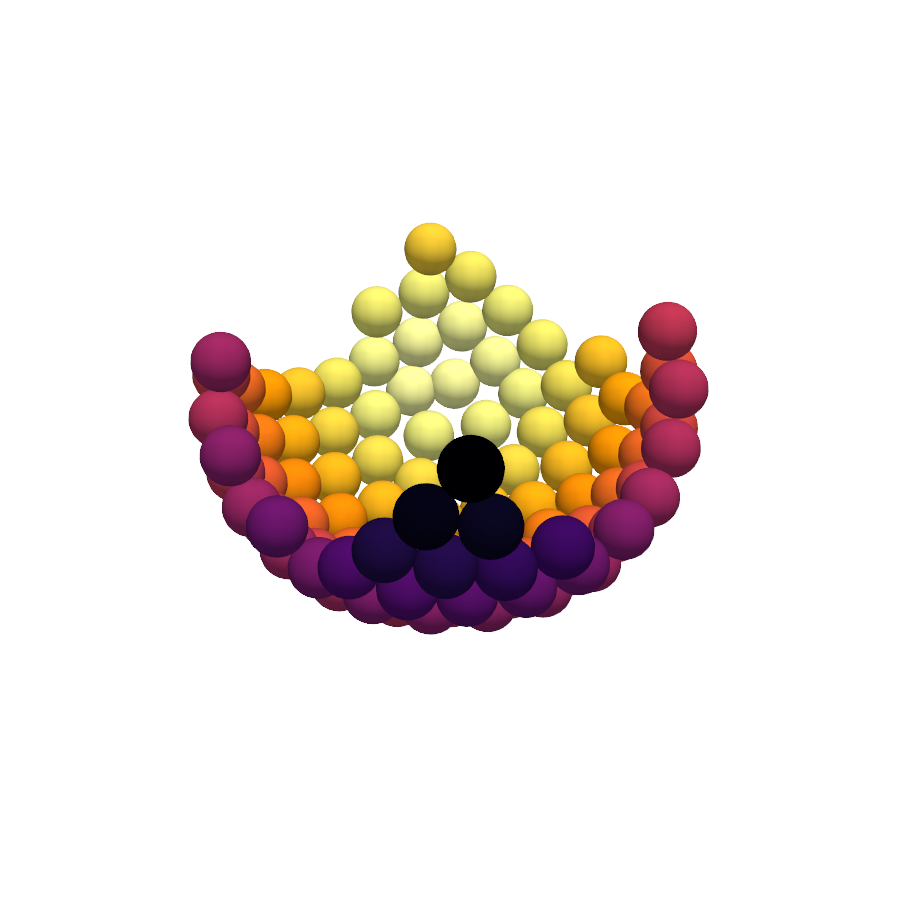

In [4]:
from pathlib import Path

import pyvista as pv
from IPython.display import Image, display
from scipy.spatial import cKDTree

# --- settings ---
WINDOW_SIZE = (900, 900)
CMAP = "inferno"  # bright colors near camera, darker farther away
ELEVATION, AZIMUTH = 35, 45
OUTPUT_PREFIX = "fig1_iso_up_spheres"
SPHERE_RADIUS = 1  # auto from nearest-neighbor spacing
SPHERE_RESOLUTION = 24  # lower = smaller SVG, higher = smoother spheres
AMBIENT, DIFFUSE = 0.18, 0.82  # headlight shading for vector export


def rgba_to_hex(rgb):
    r, g, b = (np.clip(rgb, 0, 1) * 255).astype(int)
    return f"#{r:02x}{g:02x}{b:02x}"


def world_to_display(plotter, points):
    renderer = plotter.renderer
    _, height = plotter.window_size
    out = np.empty((len(points), 3), dtype=float)
    for i, pt in enumerate(points):
        renderer.SetWorldPoint(float(pt[0]), float(pt[1]), float(pt[2]), 1.0)
        renderer.WorldToDisplay()
        dx, dy, dz = renderer.GetDisplayPoint()
        out[i] = (dx, height - 1 - dy, dz)
    return out


def shaded_face_colors(mesh, base_rgb, cam_pos):
    mesh = mesh.compute_normals(cell_normals=True, inplace=False)
    normals = np.asarray(mesh.cell_normals)
    centers = np.asarray(mesh.cell_centers().points)
    light_dirs = cam_pos - centers
    light_dirs /= np.linalg.norm(light_dirs, axis=1, keepdims=True) + 1e-12
    ndotl = np.clip((normals * light_dirs).sum(axis=1), 0.0, 1.0)
    intensity = AMBIENT + DIFFUSE * ndotl
    return np.clip(base_rgb * intensity[:, None], 0.0, 1.0)


def export_shaded_mesh_svg(filename, plotter, sphere_meshes, base_colors, cam_pos, width, height):
    """Scalable vector SVG: each triangle keeps its own shaded fill color."""
    triangles = []
    for mesh, base_rgb in zip(sphere_meshes, base_colors):
        face_colors = shaded_face_colors(mesh, base_rgb, cam_pos)
        screen = world_to_display(plotter, mesh.points)
        faces = mesh.faces.reshape(-1, 4)[:, 1:4]
        for fi, tri in enumerate(faces):
            pts = screen[tri, :2]
            depth = screen[tri, 2].mean()
            path = (
                f"M {pts[0, 0]:.4f},{pts[0, 1]:.4f} "
                f"L {pts[1, 0]:.4f},{pts[1, 1]:.4f} "
                f"L {pts[2, 0]:.4f},{pts[2, 1]:.4f} Z"
            )
            triangles.append((depth, path, rgba_to_hex(face_colors[fi])))

    triangles.sort(key=lambda item: item[0], reverse=True)
    lines = [
        '<?xml version="1.0" encoding="UTF-8"?>',
        f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 {width} {height}">',
    ]
    for _, path, color in triangles:
        lines.append(f'<path d="{path}" fill="{color}" stroke="none"/>')
    lines.append("</svg>")
    Path(filename).write_text("\n".join(lines))


x = np.asarray(iso_up_last_frame_x, dtype=float)
center = x.mean(axis=0)

if SPHERE_RADIUS is None:
    dists, _ = cKDTree(x).query(x, k=2)
    SPHERE_RADIUS = 0.35 * dists[:, 1].mean()

pv.global_theme.transparent_background = True
pl = pv.Plotter(window_size=WINDOW_SIZE, off_screen=True)
pl.set_background(None)
pl.show_axes = False

sphere_meshes = []
actors = []
for pos in x:
    sphere = pv.Sphere(
        radius=SPHERE_RADIUS,
        center=pos,
        theta_resolution=SPHERE_RESOLUTION,
        phi_resolution=SPHERE_RESOLUTION,
    )
    sphere_meshes.append(sphere)
    actors.append(
        pl.add_mesh(
            sphere,
            color="white",
            smooth_shading=True,
            specular=0.0,
            diffuse=1.0,
            ambient=AMBIENT,
            lighting=True,
            show_edges=False,
        )
    )

pl.camera.focal_point = center
pl.reset_camera()
dist = np.linalg.norm(np.array(pl.camera.position) - center)
elev = np.radians(ELEVATION)
azim = np.radians(AZIMUTH)
pl.camera.position = center + dist * np.array(
    [np.cos(elev) * np.cos(azim), np.cos(elev) * np.sin(azim), np.sin(elev)]
)
pl.camera.view_up = (0, 0, 1)
pl.camera.zoom(1.0 / (1.0 + 0.165))

cam_pos = np.array(pl.camera_position[0])
distances = np.linalg.norm(x - cam_pos, axis=1)
norm = (distances - distances.min()) / (np.ptp(distances) + 1e-9)
base_colors = plt.get_cmap(CMAP)(norm)[:, :3]

for actor, rgb in zip(actors, base_colors):
    actor.GetProperty().SetColor(*rgb)

pl.render()

w, h = WINDOW_SIZE
png_path = f"{OUTPUT_PREFIX}.png"
svg_path = f"{OUTPUT_PREFIX}.svg"
pl.screenshot(png_path, transparent_background=True)
export_shaded_mesh_svg(svg_path, pl, sphere_meshes, base_colors, cam_pos, w, h)

pl.close()
display(Image(filename=png_path))


In [5]:
# Importing the datasets to plot

grand_folder = '24_06_Figure_data/fig1/'

iso_up      = np.load(grand_folder + 'iso_up_20/data.pkl', allow_pickle=True)
iso_down    = np.load(grand_folder + 'iso_down_20/data.pkl', allow_pickle=True)
pringle_du  = np.load(grand_folder + 'pringle_downup_20/data.pkl', allow_pickle=True)
pringle_ud  = np.load(grand_folder + 'pringle_updown_20/data.pkl', allow_pickle=True)
basecase    = np.load(grand_folder + 'plain_basecase/data.pkl', allow_pickle=True)
aniso_perp   = np.load(grand_folder + 'perp_angle_20/data.pkl', allow_pickle=True)
aniso_par  = np.load(grand_folder + 'par_angle_20/data.pkl', allow_pickle=True)

In [6]:
from figure_rendering import (
    RENDER_SETTINGS,
    render_cluster_panel,
    plot_radial_comparison,
    plot_dual_basecase_comparison,
)


In [7]:
# --- colormap tuning (passed via render_settings to all panels) ---
COLOR_SETTINGS = {
    "cmap": "plasma",
    "cmin": 30,
    "cmax": None,
    "bright_near_camera": True,  # False flips: far cells become brighter
}


In [ ]:
# --- Voronoi inter-cell edge styling ---
VORONOI_EDGE_SETTINGS = {
    "voronoi_edge_color": "#000000",
    "voronoi_edge_width": 2.5,
}


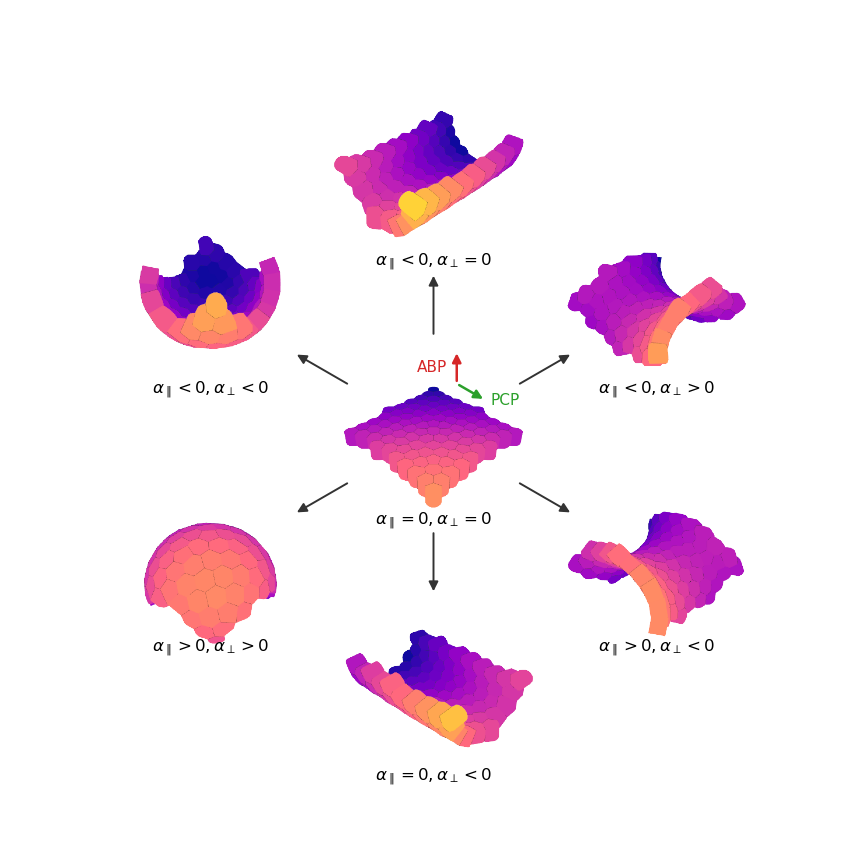

In [8]:
# --- configure 7 datasets (replace any entry freely) ---
datasets = [
    {"x": aniso_par["x"][-2], "p": aniso_par["p"][-2], "label": f"$\\alpha_\parallel < 0, \\alpha_\perp = 0$"},
    {"x": pringle_ud["x"][-2], "p": pringle_ud["p"][-2], "label": f"$\\alpha_\parallel < 0, \\alpha_\perp > 0$"},
    {"x": pringle_du["x"][-2], "p": pringle_du["p"][-2], "label": f"$\\alpha_\parallel > 0, \\alpha_\perp < 0$"},
    {"x": aniso_perp["x"][-2], "p": aniso_perp["p"][-2], "label": f"$\\alpha_\parallel = 0, \\alpha_\perp < 0$"},
    {"x": iso_down["x"][-10], "p": iso_down["p"][-10], "label": f"$\\alpha_\parallel > 0, \\alpha_\perp > 0$"},
    {"x": iso_up["x"][-2], "p": iso_up["p"][-2], "label": f"$\\alpha_\parallel < 0, \\alpha_\perp < 0$"},
    {"x": basecase["x"][-2], "p": basecase["p"][-2], "label": f"$\\alpha_\parallel = 0, \\alpha_\perp = 0$"},
]

fig = plot_radial_comparison(
    datasets,
    center_index=6,
    render_mode="voronoi",
    render_settings={**COLOR_SETTINGS, **VORONOI_EDGE_SETTINGS, "border_cap": 2.0, "show_voronoi_edges": True, "neighbor_search_factor": 1.6},
    output_path="fig_radial_voronoi_comparison.png",
)
plt.show()


In [9]:
grand_folder = '24_06_Figure_data/fig2/'

plain_basecase    = np.load(grand_folder + 'plain_basecase/data.pkl', allow_pickle=True)
plain_g15      = np.load(grand_folder + 'gamma_1.5/data.pkl', allow_pickle=True)
plain_g06    = np.load(grand_folder + 'gamma_0.66/data.pkl', allow_pickle=True)

cyl_basecase    = np.load(grand_folder + 'cylinder_basecase_par/data.pkl', allow_pickle=True)
cyl_g15      = np.load(grand_folder + 'cylinder_gamma_1.5/data.pkl', allow_pickle=True)
cyl_g06    = np.load(grand_folder + 'cylinder_gamma_0.66/data.pkl', allow_pickle=True)

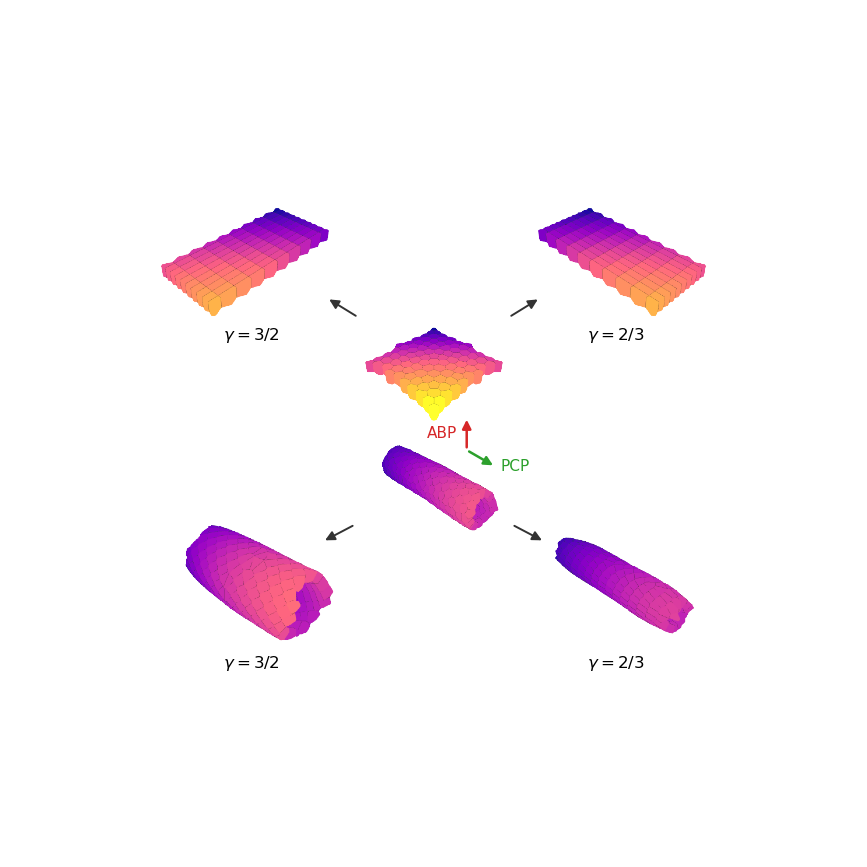

In [12]:
# --- colormap tuning (passed via render_settings to all panels) ---
COLOR_SETTINGS = {
    "cmap": "plasma",
    "cmin": 40,
    "cmax": None,
    "bright_near_camera": True,  # False flips: far cells become brighter
}


groups = [
    {
        "base": {"x": plain_basecase["x"][-2], "p": plain_basecase["p"][-2]},
        "transforms": [
            {"x": plain_g15["x"][-2], "p": plain_g15["p"][-2], "label": r"$\gamma = 3/2$", "corner": "up_left"},
            {"x": plain_g06["x"][-2], "p": plain_g06["p"][-2], "label": r"$\gamma = 2/3$", "corner": "up_right"},
        ],
    },
    {
        "base": {"x": cyl_basecase["x"][-2], "p": cyl_basecase["p"][-2]},
        "rotation": {"axis": "x", "degrees": 90},
        "transforms": [
            {"x": cyl_g15["x"][-2], "p": cyl_g15["p"][-2], "label": r"$\gamma = 3/2$", "corner": "down_left"},
            {"x": cyl_g06["x"][-2], "p": cyl_g06["p"][-2], "label": r"$\gamma = 2/3$", "corner": "down_right"},
        ],
    },
]

fig2 = plot_dual_basecase_comparison(
    groups,
    render_mode="voronoi",
    render_settings={**COLOR_SETTINGS, **VORONOI_EDGE_SETTINGS, "border_cap": 1.0, "show_voronoi_edges": True, "neighbor_search_factor": 2.5},
    output_path="fig_dual_voronoi_comparison.png",
)
plt.show()
